# End-to-End MLOps with Kubeflow: California Housing Prices

Welcome to this comprehensive demonstration of the **Kubeflow** ecosystem. In this notebook, we will transition from a "local" experimental mindset to a structured, automated, and production-ready MLOps workflow.

Building a machine learning model is often only the beginning; the real challenge lies in scaling, tracking, and deploying that model efficiently. Using the **California Housing dataset**, we will walk through the entire lifecycle of a machine learning project.

---

## 🚀 The Workflow Journey

### 1. Exploration & Prototyping
Every great project starts with understanding the data. We begin within this notebook environment to perform **Exploratory Data Analysis (EDA)** and prototype a simple modelling pipeline to predict housing prices.

### 2. Experiment Tracking with MLFlow
Metadata is the lifeblood of MLOps. You will learn how to integrate **MLFlow** to log your parameters, metrics, and version your model artifacts, ensuring that every experiment is reproducible and traceable.

### 3. Hyperparameter Tuning with Katib
Why tune parameters manually? We will leverage **Katib**, Kubeflow’s hyperparameter tuning engine, to automatically find the optimal configuration for our model, significantly improving performance without manual trial-and-error.

### 4. Orchestration with Kubeflow Pipelines (KFP)
We will formalize our logic by creating a **KFP pipeline**. This transforms our workflow into a series of modular, reusable components:
* **Preprocessing:** Cleaning and scaling the raw data.
* **Modelling:** Training the regression model.
* **Registration:** Automatically storing the trained model into MLFlow.

### 5. Production Serving with KServe
Finally, we move from a static model to a live service. We will showcase how to use **KServe** to deploy an inference service, allowing you to consume your model via a scalable API endpoint.

---

## 🛠 Prerequisites

Before we dive in, ensure your environment is set up:
* Access to a **Kubeflow** cluster.
* A configured **MLFlow** tracking URI.

By the end of this tutorial, you will have a complete blueprint for taking a raw dataset and turning it into a managed, scalable machine learning service.

**Let's begin!**

We first install the Python requirements, including the Python SDKs to interact with Kubeflow (e.g. ``kfp`, `kubeflow-katib`, `mlflow`, and `kserve`).

In [1]:
!pip install -r requirements.txt

INFO: pip is looking at multiple versions of kserve to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 116.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 535.2/535.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 88.9 MB/s eta 0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 7.0.0
    Uninstalling psutil-7.0.0:
      Successfully uninstalled psutil-7.0.0
  Attempting uninstall: protobuf━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/21 [psutil]
    Found existing installation: protobuf 6.30.2━━━━━━━━━━━━━━  2/21 [psutil]
    Uninstalling protobuf-6.30.2:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/21 [psutil]
      Successfully uninstalled protobuf-6.30.2━━━━━━━━━━━━━━━━  2/21 [psutil]
  Attempting uninstall: prometheus-client━━━━━━━━━━━━━━━━━━━━━  2/21 [psutil]
    Found existing installation: prometheus_client 0.22.1━━━━━  2/21 [psu

## Data exploration

We'll start by diving into the California Housing dataset, a classic benchmark for regression tasks containing features like median income, house age, and proximity to the ocean. In the initial data exploration, you may visualize feature correlations and handle missing values to build a solid foundation. In the following we will just do a simple plot of the target variable distribution.

In [2]:
import sklearn

In [3]:
from sklearn.datasets import fetch_california_housing

# Fetch the dataset as a bunch object containing a DataFrame
california = fetch_california_housing(as_frame=True)

# Access the combined DataFrame (Features + Target)
df = california.frame

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<Axes: >

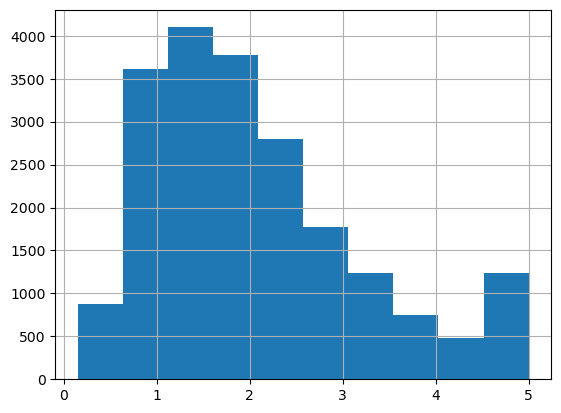

In [5]:
df["MedHouseVal"].hist()

## Training models

For the modeling phase, we will develop a regression model designed to predict median house values based on the California dataset’s spatial and economic features. We will start with a simple scikit-learn pipeline, emphasizing the transition from a standard Python script to a modular structure that is ready for the cloud. This step focuses on establishing a robust baseline, ensuring our model logic is sound before we hand it off to Katib for automated optimization and MLFlow for versioning.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

import pandas as pd

# Define the target column for prediction
target_column = "MedHouseVal"

# Split the data into training and testing sets
train_x, test_x, train_y, test_y = train_test_split(
    df.drop(columns=[target_column]),
    df[target_column],
    test_size=0.25,
    random_state=42
)

model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

model.fit(train_x, train_y)

score = model.score(test_x, test_y)

print(f"Model R² Score: {score:.4f}")

Model R² Score: 0.8079


## Use MLFlow

Once our model is trained, we transition from local variables to persistent management by storing the model in MLFlow. This step acts as our digital ledger, where we log the specific hyperparameters used, performance metrics like the R2 score, and the model binaries themselves. By registering the model in the MLFlow Model Registry, we ensure that every iteration is versioned and easily retrievable for future deployment or comparison.

In [7]:
import mlflow
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

import pandas as pd

# Define the target column for prediction
target_column = "MedHouseVal"

# Split the data into training and testing sets
train_x, test_x, train_y, test_y = train_test_split(
    df.drop(columns=[target_column]),
    df[target_column],
    test_size=0.25,
    random_state=42
)

# Enable MLflow auto logging for scikit-learn models
mlflow.sklearn.autolog()

with mlflow.start_run(run_name="my-run") as run:
    mlflow.set_tag("author", "kf-testing")

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
    ])
    
    model.fit(train_x, train_y)

    score = model.score(test_x, test_y)

    mlflow.log_metric("test_r2", score)
    
    model_uri = f"{run.info.artifact_uri}/model"
    print(model_uri)

    mlflow.sklearn.log_model(model, "model", registered_model_name="my-test-model")

/opt/conda/lib/python3.11/site-packages/mlflow/utils/requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251
2026/05/07 22:31:35 WARNING mlflow.utils.autologging_utils: You are using an unsupported version of sklearn. If you encounter errors during autologging, try upgrading / downgrading sklearn to a supported version, or try upgrading MLflow.


s3://mlflow/0/80c927d2493d4cdc9ca52e2db419c28e/artifacts/model


/opt/conda/lib/python3.11/site-packages/_distutils_hack/__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(
Successfully registered model 'my-test-model'.
2026/05/07 22:31:57 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to 

# Using Katib

To optimize our model's performance, we will utilize Katib, Kubeflow's native hyperparameter tuning component. Instead of guessing the number of estimators, we define a search space and let Katib handle the heavy lifting of running parallel experiments to find the "sweet spot" for our housing predictions. This automated approach ensures we achieve the highest possible accuracy with the California dataset while minimizing manual trial-and-error.

In [8]:
from kubeflow.katib import KatibClient, search

def train_fn(parameters):
    from sklearn.datasets import fetch_california_housing
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import r2_score
    
    # Parameters are passed as a dictionary
    n_estimators = int(parameters["regressor__n_estimators"])

    # Fetch the dataset as a bunch object containing a DataFrame
    california = fetch_california_housing(as_frame=True)
    
    # Access the combined DataFrame (Features + Target)
    df = california.frame

    # Define the target column for prediction
    target_column = "MedHouseVal"
    
    train_x, test_x, train_y, test_y = train_test_split(
        df.drop(columns=[target_column]),
        df[target_column],
        test_size=0.25,
        random_state=42
    )
    
    # Define and train pipeline
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', RandomForestRegressor(n_estimators=n_estimators, random_state=42))
    ])
    
    model.fit(train_x, train_y)

    r2 = model.score(test_x, test_y)
    
    # Important: The function must print the metric for Katib to capture it
    print(f"R2={r2}")

# 2. Initialize Katib Client
client = KatibClient()

# 3. Configure and run the experiment
client.tune(
    name="housing-estimators-tune",
    objective=train_fn,
    parameters={
        "regressor__n_estimators": search.int(min=50, max=200)
    },
    objective_metric_name="R2",
    objective_type="maximize",
    max_trial_count=10,
    parallel_trial_count=4,
    base_image="python:3.11",
    packages_to_install=["scikit-learn", "pandas", "numpy"]
)

## Using KFP 

To tie everything together, we will orchestrate the entire workflow using **Kubeflow Pipelines (KFP)**. This is where we shift from individual experiments to a production-grade, end-to-end automated system. 

By defining our process as a directed acyclic graph (DAG), we will build a cohesive pipeline that handles:
* **Data Preprocessing:** Automating the transformation of the California Housing data.
* **Model Training and MLFlow Integration:** Leveraging on the knowledge gathered using Katib, we will train the model using the selected number of estimators and ensuring the resulting model and its metadata are securely versioned and stored.
* **Automated Deployment:** Finalizing the flow by consuming the registered model to trigger a **KServe** inference service.

This transformation turns our manual data science steps into a repeatable, scalable, and manageable machine learning lifecycle.

We first define the single steps of the Pipelines:

* `create_dataset` to fetch the dataset and create a Parquet file
* `train_model` to train a model on the entire dataset with a given number of estimators, and store it in MLFlow
* `deploy_model` to consume the model from MLflow and deploy an inference service using KServe

In [9]:
import kfp
import mlflow
import os
import requests

from kfp.dsl import Input, Model, component
from kfp.dsl import InputPath, OutputPath, pipeline, component
from kserve import KServeClient
from mlflow.tracking import MlflowClient
from tenacity import retry, stop_after_attempt, wait_exponential

@component(
    base_image="python:3.11",  # Use Python 3.11 base image
    packages_to_install=["pandas==2.3.3", "pyarrow==19.0.1", "scikit-learn==1.8.0"],
)
def create_dataset(output_file: OutputPath("Dataset")) -> None:
    from sklearn.datasets import fetch_california_housing

    # Fetch the dataset as a bunch object containing a DataFrame
    california = fetch_california_housing(as_frame=True)
    
    # Access the combined DataFrame (Features + Target)
    df = california.frame

    df.to_parquet(output_file)

@component(
    base_image="python:3.11",  # Use Python 3.11 base image
    packages_to_install=[
        "pandas==2.3.3",
        "scikit-learn==1.8.0",
        "mlflow==2.22.4",
        "pyarrow==19.0.1",
        "boto3==1.42.37",
    ],
)
def train_model(dataset: InputPath("Dataset"), n_estimators: int, run_name: str, model_name: str) -> str:
    import os
    import mlflow
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import r2_score
    
    import pandas as pd

    # Load the preprocessed dataset
    df = pd.read_parquet(dataset)

    # Define the target column for prediction
    target_column = "MedHouseVal"
    
    # Split the data into training and testing sets
    train_x, test_x, train_y, test_y = train_test_split(
        df.drop(columns=[target_column]),
        df[target_column],
        test_size=0.25,
        random_state=42
    )
    
    # Enable MLflow auto logging for scikit-learn models
    mlflow.sklearn.autolog()
    
    with mlflow.start_run(run_name=run_name) as run:
        mlflow.set_tag("author", "kf-testing")
    
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', RandomForestRegressor(n_estimators=n_estimators, random_state=42))
        ])
        
        model.fit(train_x, train_y)
    
        score = model.score(test_x, test_y)
    
        mlflow.log_metric("test_r2", score)
        mlflow.sklearn.log_model(model, "model", registered_model_name=model_name)
        
        # Return the model artifact URI as a string
        model_uri = f"{run.info.artifact_uri}/model"
        print(model_uri)
        return model_uri


@component(
    base_image="python:3.11",  # Use Python 3.11 base image
    packages_to_install=["kserve==0.15.2", "kubernetes==30.1.0", "tenacity==9.1.2"],
)
def deploy_model(model_uri: str, isvc_name: str) -> str:
    from kubernetes.client import V1ObjectMeta
    from kserve import (
        constants,
        KServeClient,
        V1beta1InferenceService,
        V1beta1InferenceServiceSpec,
        V1beta1PredictorSpec,
        V1beta1SKLearnSpec,
    )
    from tenacity import retry, wait_exponential, stop_after_attempt

    # Initialize the Inference Service specification
    isvc = V1beta1InferenceService(
        api_version=constants.KSERVE_V1BETA1,
        kind=constants.KSERVE_KIND_INFERENCESERVICE,
        metadata=V1ObjectMeta(
            name=isvc_name,
            annotations={"sidecar.istio.io/inject": "false"},
        ),
        spec=V1beta1InferenceServiceSpec(
            predictor=V1beta1PredictorSpec(
                service_account_name="kserve-controller-s3",
                sklearn=V1beta1SKLearnSpec(storage_uri=model_uri),
            )
        ),
    )

    # Deploy the Inference Service using KServe
    client = KServeClient()
    client.create(isvc)

    # Retry logic to ensure the Inference Service is ready
    @retry(
        wait=wait_exponential(multiplier=2, min=1, max=10),
        stop=stop_after_attempt(30),
        reraise=True,
    )
    def assert_isvc_created(client, isvc_name):
        assert client.is_isvc_ready(isvc_name), f"Failed to create Inference Service {isvc_name}."

    # Wait until the service is ready and get the service URL
    assert_isvc_created(client, isvc_name)
    isvc_resp = client.get(isvc_name)
    isvc_url = isvc_resp["status"]["address"]["url"]
    print("Inference URL:", isvc_url)

    return isvc_url

Now that we have created all the single steps, we aggregate them into a full DAG, i.e. a KFP Pipeline.

In [11]:
# Define a constant for the Inference Service name
ISVC_NAME = "housing-regressor"
MLFLOW_RUN_NAME = "regressor-pipeline-xyz"
MLFLOW_MODEL_NAME = "regressor-pipeline"

# Fetch environment variables for MLflow tracking and AWS credentials
# These are guaranteed to be present because of the mlflow's poddefault please refer to [this guide](https://documentation.ubuntu.com/charmed-mlflow/en/latest/tutorial/mlflow-kubeflow/

mlflow_tracking_uri = os.getenv("MLFLOW_TRACKING_URI")
mlflow_s3_endpoint_url = os.getenv("MLFLOW_S3_ENDPOINT_URL")
aws_access_key_id = os.getenv("AWS_ACCESS_KEY_ID")
aws_secret_access_key = os.getenv("AWS_SECRET_ACCESS_KEY")

@pipeline(name="download-preprocess-train-deploy-pipeline")
def download_preprocess_train_deploy_pipeline(n_estimators: int):
    # Step 1: Download the dataset and preprocess the downloaded dataset
    preprocess_task = create_dataset()

    # Step 2: Train the model on the preprocessed dataset
    train_task = (
        train_model(
            dataset=preprocess_task.outputs["output_file"],
            n_estimators=n_estimators,
            run_name=MLFLOW_RUN_NAME,
            model_name=MLFLOW_MODEL_NAME,
        )
        .set_env_variable(name="MLFLOW_TRACKING_URI", value=mlflow_tracking_uri)
        .set_env_variable(name="MLFLOW_S3_ENDPOINT_URL", value=mlflow_s3_endpoint_url)
        .set_env_variable(name="AWS_ACCESS_KEY_ID", value=aws_access_key_id)
        .set_env_variable(name="AWS_SECRET_ACCESS_KEY", value=aws_secret_access_key)
    )

    # Step 3: Deploy the trained model with KServe
    deploy_task = deploy_model(
        model_uri=train_task.output, isvc_name=ISVC_NAME
    ).set_env_variable(name="AWS_SECRET_ACCESS_KEY", value=aws_secret_access_key)

Once the Pipeline is created, we can deploy it using the `kfp` SDK.

In [12]:
import kfp

client = kfp.Client()

kfp.compiler.Compiler().compile(
    download_preprocess_train_deploy_pipeline, "download_preprocess_train_deploy_pipeline.yaml"
)

run = client.create_run_from_pipeline_func(
    download_preprocess_train_deploy_pipeline, arguments={"n_estimators":199}, enable_caching=False
)

/opt/conda/lib/python3.11/site-packages/kfp/client/client.py:159: FutureWarning: This client only works with Kubeflow Pipeline v2.0.0-beta.2 and later versions.
  warnings.warn(


## Inference Service

Once the deployment is triggered, we move to the Model Validation phase. Here, we verify that the KServe inference service is fully operational and ready for production traffic. We will demonstrate how to construct a sample payload from the California Housing test set and send an HTTP POST request to the model's endpoint. By checking the returned predictions and response codes, we ensure the entire pipeline—from raw data to a live, queryable API—is functioning perfectly.

In [ ]:
# Initialize the KServe client
# This client is used to interact with the KServe Inference Service.
kserve_client = KServeClient()

# Retrieve the Inference Service details
# Fetches the Inference Service by name and extracts the URL for making predictions.
isvc_resp = kserve_client.get(ISVC_NAME)
inference_service_url = isvc_resp["status"]["address"]["url"]
print("Inference URL:", inference_service_url)

# Define the input data for prediction
# This data matches the expected input format of the deployed model, with each instance being a list of feature values.
input_data = {
    "instances": [
        [ 1.68120000e+00,  2.50000000e+01,  4.19220056e+00, 1.02228412e+00,  1.39200000e+03,  3.87743733e+00, 3.60600000e+01, -1.19010000e+02],
        [ 2.53130000e+00,  3.00000000e+01,  5.03938356e+00, 1.19349315e+00,  1.56500000e+03,  2.67979452e+00, 3.51400000e+01, -1.19460000e+02]
    ]
}

# Send a prediction request to the Inference Service
# This sends the input data to the model for prediction via a POST request and prints the response.
response = requests.post(f"{inference_service_url}/v1/models/{ISVC_NAME}:predict", json=input_data)
print(response.text)